### Celle 1 — Biblioteker
**Overvejelse:** Vi samler imports i starten, så notebooken er overskuelig og reproducerbar.

**Hvorfor metoderne bruges:**
- `pandas`/`numpy` til datahåndtering og beregninger
- `matplotlib`/`seaborn` til visualisering af tidsserier
- `scipy.signal` til signal- og støjrelaterede metoder (hvis nødvendigt)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
from IPython.display import display


### Celle 2 — Indlæsning af data
**Overvejelse:** Train- og testfiler indlæses separat, så datastrukturen kan verificeres inden de kombineres.

**Hvorfor metoden bruges:** Tidlig kontrol af inputdata reducerer risikoen for fejl senere i analysen.

In [4]:
print("Loader Train og Test data...")
train_df = pd.read_csv('DailyDelhiClimateTrain.csv')
test_df = pd.read_csv('DailyDelhiClimateTest.csv')

Loader Train og Test data...


### Celle 3 — Samle og klargør tidsserier
**Overvejelse:** Vi kombinerer datasættene, sorterer på dato og vælger numeriske kolonner, så tidsserieanalysen bliver konsistent.

**Hvorfor metoden bruges:** Korrekt tidsorden og ensartede variabler er nødvendigt for at kunne vurdere støj og anvende vinduesmetoden korrekt.

In [5]:
# Kombiner train og test, så vi analyserer hele tidsforløbet
climate_df = pd.concat([train_df, test_df], ignore_index=True)
climate_df['date'] = pd.to_datetime(climate_df['date'])
climate_df = climate_df.sort_values('date').reset_index(drop=True)

# Vaelg numeriske tidsserier
numeric_cols = climate_df.select_dtypes(include='number').columns.tolist()
print('Numeriske tidsserier:', numeric_cols)

climate_df.head()

Numeriske tidsserier: ['meantemp', 'humidity', 'wind_speed', 'meanpressure']


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


### Celle 4 — Vurdering af støjniveau via datavisualisering
**Overvejelse:** Støjniveau vurderes ved at sammenligne original signalserie med en glattet trend (7-dages glidende gennemsnit).

**Hvorfor metoden bruges:**
- Original vs. trend viser, hvor meget kortsigtet variation der findes
- Residualen (`støj = original - trend`) isolerer støjkomponenten
- `noise_ratio = std(støj) / std(original)` giver en enkel, sammenlignelig måling på tværs af serier

**Fortolkning:**
- Lav `noise_ratio` indikerer lav støj
- Høj `noise_ratio` indikerer, at en stor del af variationen er kortsigtede udsving

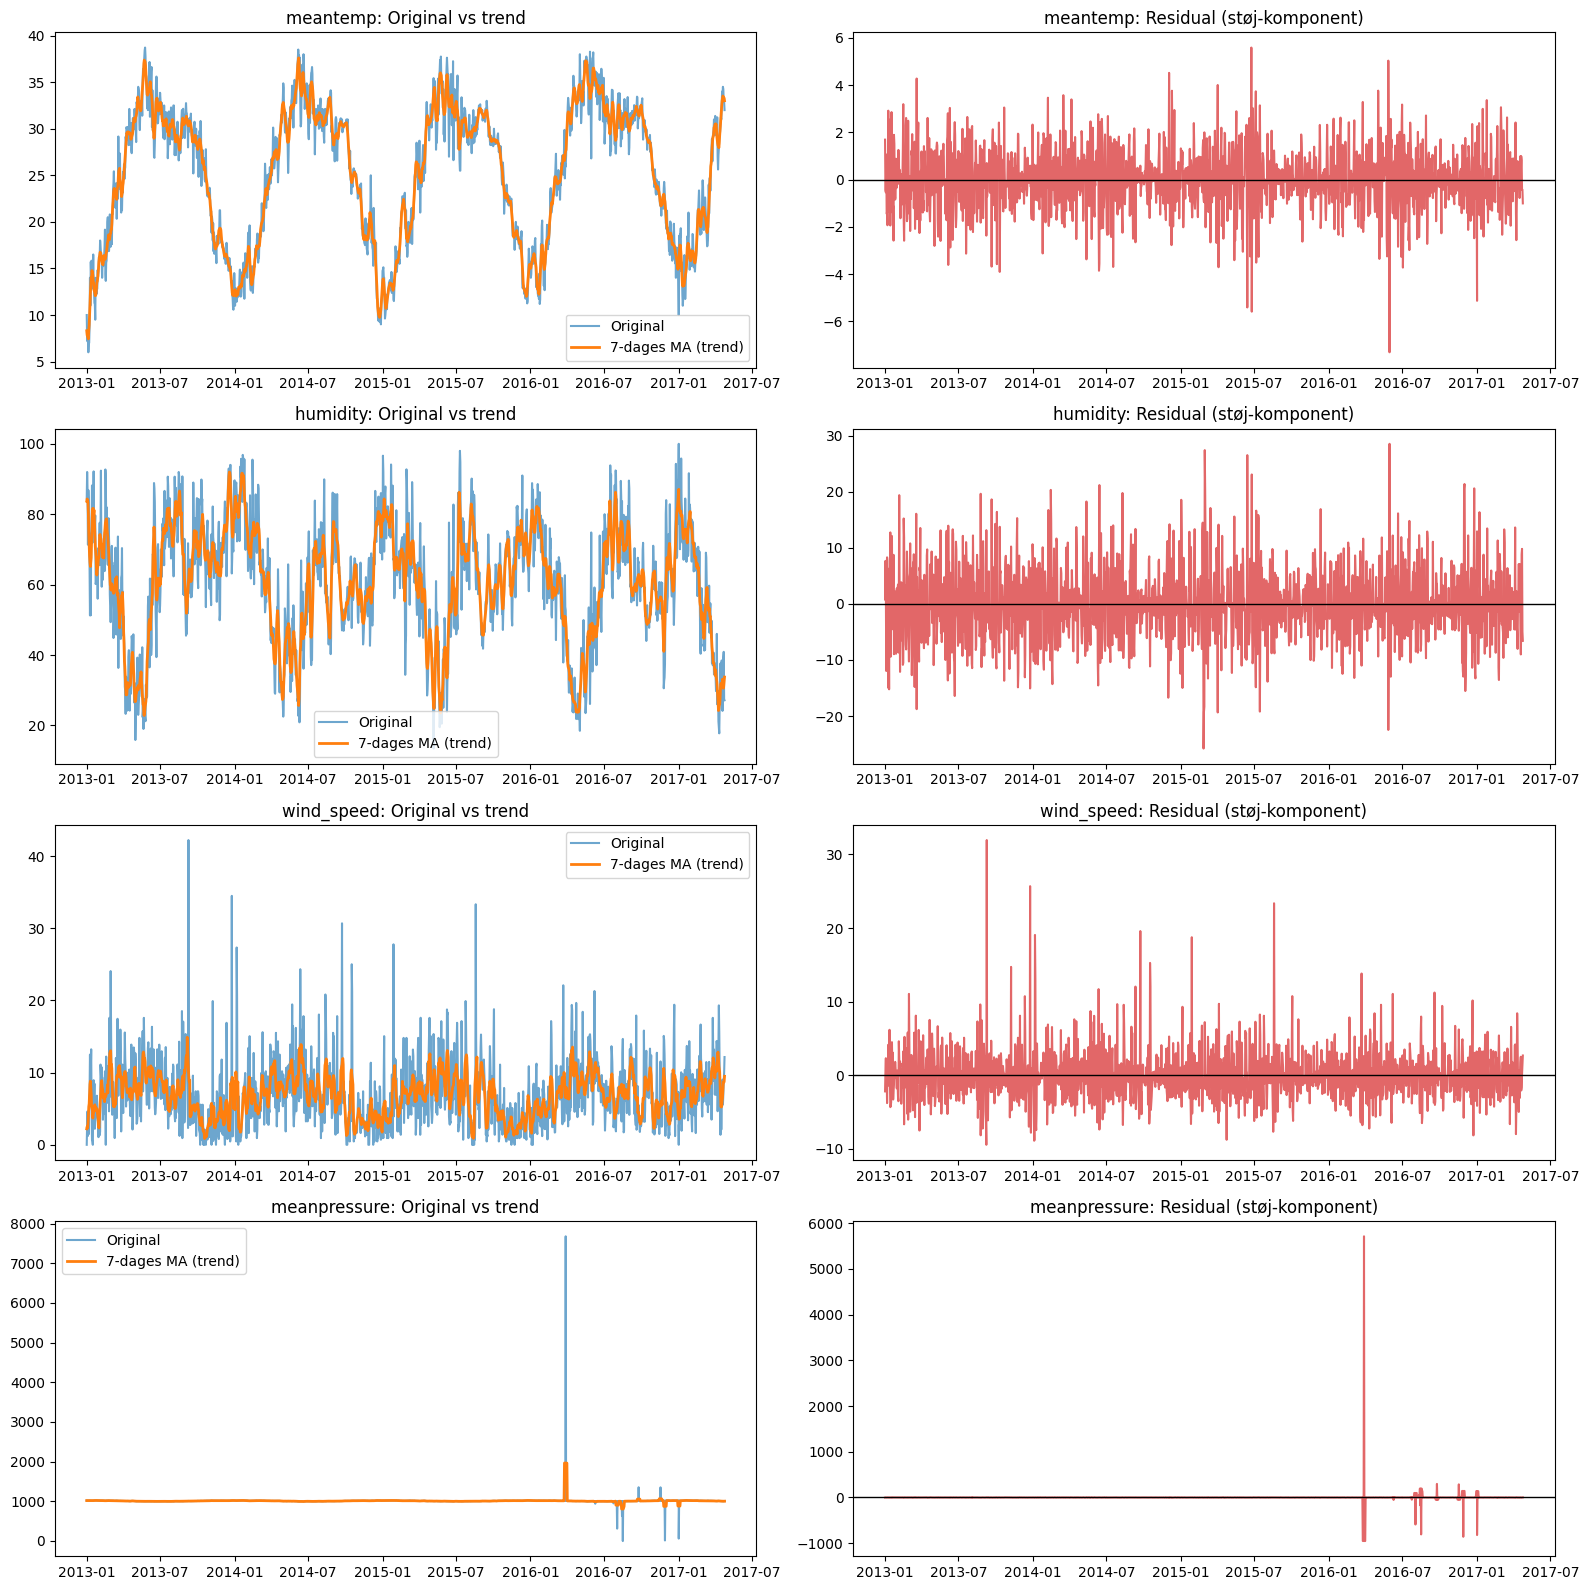

Vurderet støjniveau pr. tidsserie:


,serie,noise_ratio,vurdering
3,meanpressure,0.923,Høj støj
2,wind_speed,0.774,Høj støj
1,humidity,0.385,Moderat støj
0,meantemp,0.176,Lav støj


In [6]:
window = 7  # 7-dages moving average til trendestimat # Vigtigt at uddyde med en kommentar om hvorfor 7 dage er valgt
noise_summary = []

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(16, 4 * len(numeric_cols)), sharex=False)
if len(numeric_cols) == 1:
    axes = np.array([axes])

for i, col in enumerate(numeric_cols):
    s = climate_df[col]
    trend = s.rolling(window=window, center=True, min_periods=1).mean()
    noise = s - trend

    noise_ratio = noise.std() / s.std() if s.std() != 0 else 0 # uddybende kommentar om hvorfor vi bruger standardafvigelse som mål for støj og hvorfor vi sammenligner det med den originale standardafvigelse
    if noise_ratio < 0.20:
        grade = 'Lav støj'
    elif noise_ratio < 0.40:
        grade = 'Moderat støj'
    else:
        grade = 'Høj støj'

    noise_summary.append({
        'serie': col,
        'noise_ratio': noise_ratio,
        'vurdering': grade
    })

    axes[i, 0].plot(climate_df['date'], s, label='Original', alpha=0.65)
    axes[i, 0].plot(climate_df['date'], trend, label=f'{window}-dages MA (trend)', linewidth=2)
    axes[i, 0].set_title(f'{col}: Original vs trend')
    axes[i, 0].legend()

    axes[i, 1].plot(climate_df['date'], noise, color='tab:red', alpha=0.7)
    axes[i, 1].axhline(0, color='black', linewidth=1)
    axes[i, 1].set_title(f'{col}: Residual (støj-komponent)')

plt.tight_layout()
plt.show()

noise_df = pd.DataFrame(noise_summary).sort_values('noise_ratio', ascending=False)
noise_df['noise_ratio'] = noise_df['noise_ratio'].round(3)
print('Vurderet støjniveau pr. tidsserie:')
display(noise_df)

### Celle 5 — Præprocessering med vinduesmetoden (for/efter)
**Overvejelse:** Som præprocessering anvendes et 7-dages glidende gennemsnit, der reducerer støj uden at fjerne den overordnede udvikling i tidsserien.

**Hvorfor vindue = 7:** Data er daglige observationer, og et 7-dages vindue svarer til én uge. Dermed udjævnes kortsigtede dag-til-dag udsving, mens de vigtigste ugentlige/sæsonmæssige mønstre bevares.

**Metode (vinduesmetoden):**
$$
x_t^{(smooth)} = \frac{1}{7}\sum_{i=0}^{6} x_{t-i}
$$

**Hvorfor metoden bruges:**
- Dæmper dag-til-dag udsving
- Gør trend og mønstre tydeligere
- Forbereder data bedre til videre analyse/modellering

**Plot før og efter:** I den næste kodecelle vises original data (før) og glattet data (efter) i samme figur for hver numerisk tidsserie.

**Konklusion:**
- `meantemp` viser tydelig sæsonvariation med relativt moderat støj, mens `humidity` har større kortsigtede udsving.
- `wind_speed` er mere spids og variabel med flere markante peaks, hvilket indikerer højere støj i korte intervaller.
- `meanpressure` indeholder ekstreme outliers, så en robust metode som rolling median eller eksplicit outlier-håndtering er mere passende for netop denne variabel.

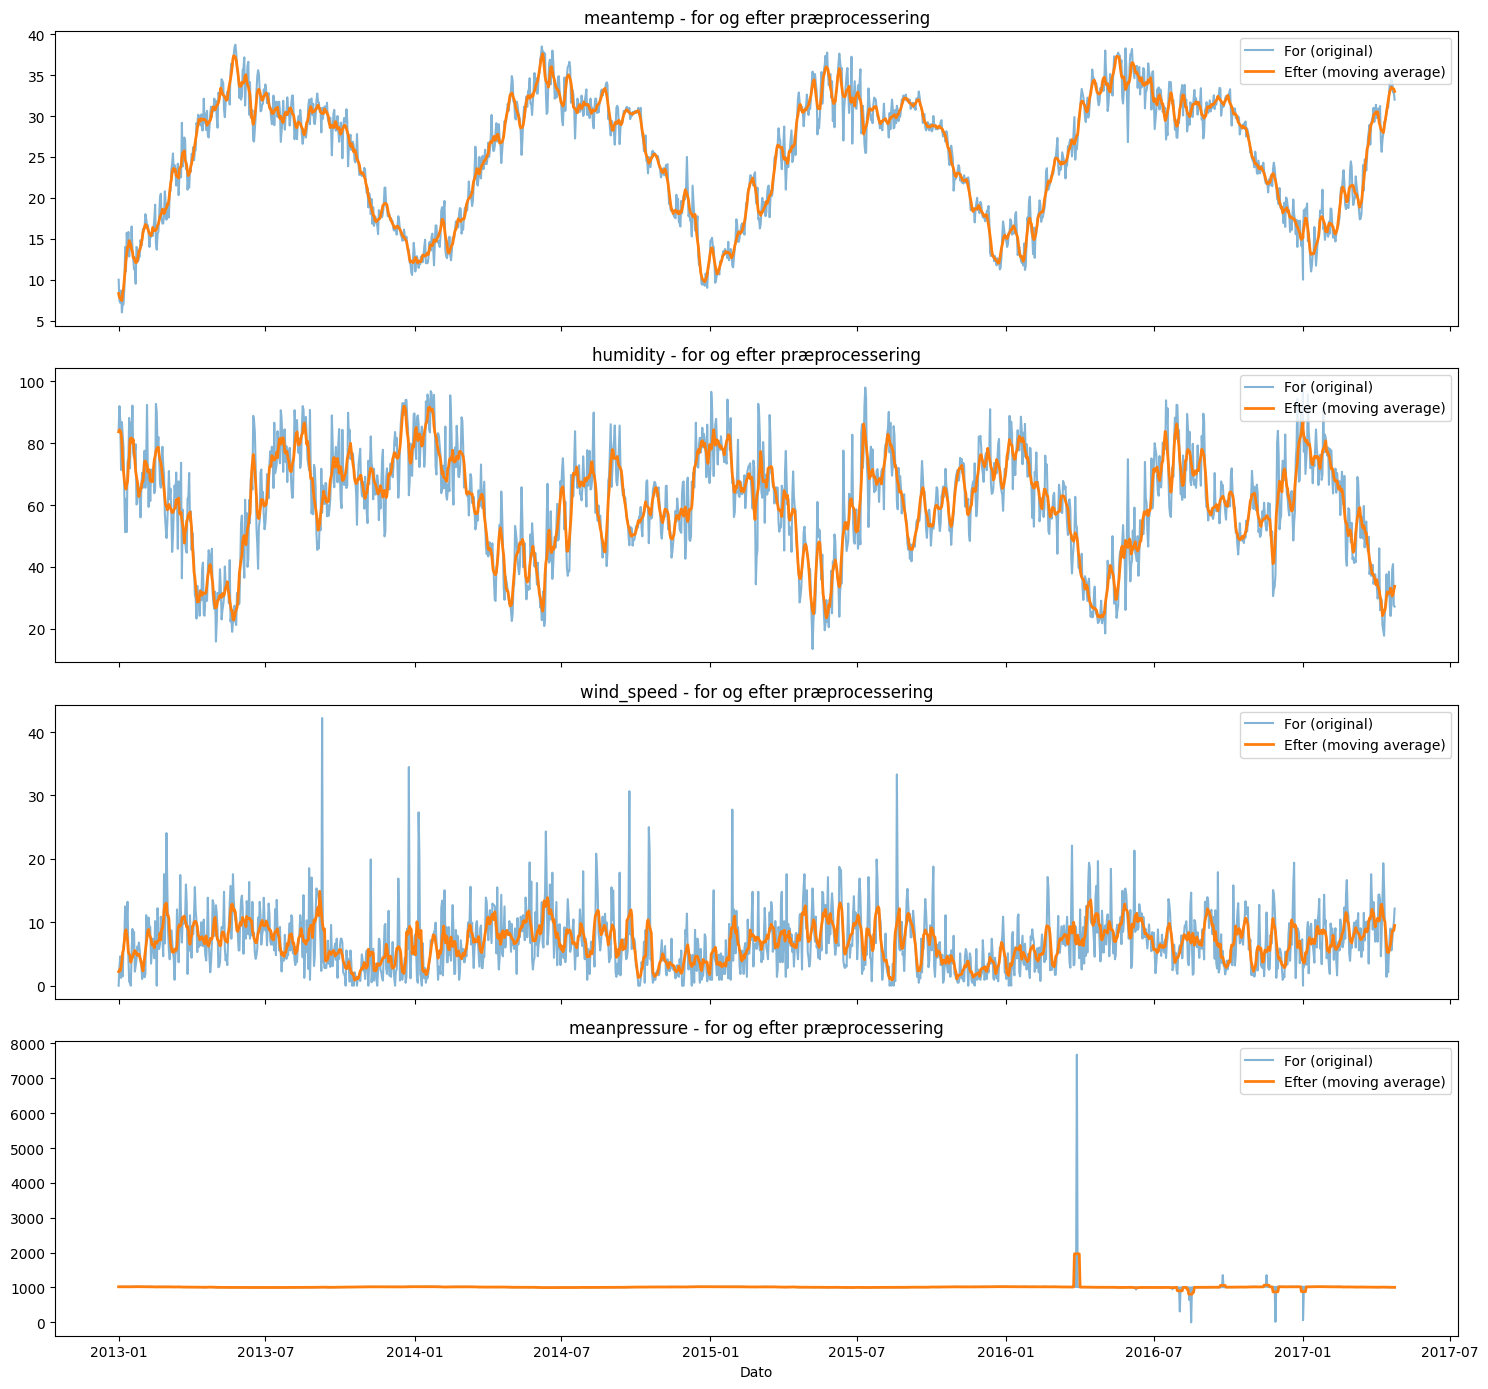

In [7]:
# Smoothet version af alle numeriske tidsserier
smoothed_df = climate_df.copy()
for col in numeric_cols:
    smoothed_df[col] = climate_df[col].rolling(window=window, center=True, min_periods=1).mean()

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(15, 3.5 * len(numeric_cols)), sharex=True)
if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    axes[i].plot(climate_df['date'], climate_df[col], label='For (original)', alpha=0.55)
    axes[i].plot(smoothed_df['date'], smoothed_df[col], label='Efter (moving average)', linewidth=2)
    axes[i].set_title(f'{col} - for og efter præprocessering')
    axes[i].legend(loc='upper right')

plt.xlabel('Dato')
plt.tight_layout()
plt.show()

### Celle 6 — Samlet konklusion
Præprocesseringen med 7-dages vinduesmetode reducerer tydeligt kortsigtet støj i alle tidsserier og gør de overordnede mønstre lettere at fortolke. `meantemp` bevarer en klar sæsonstruktur, mens `humidity` og `wind_speed` fortsat viser mere volatil adfærd, men i en mere glattet form.

For `meanpressure` ses ekstreme outliers, som påvirker både trend og residual markant. Derfor er en robust tilgang som rolling median eller eksplicit outlier-håndtering mere passende for denne variabel end et simpelt glidende gennemsnit alene.

**Konklusion på modellerne:**
- Trendmodellen (7-dages moving average) fungerer godt til at fremhæve underliggende mønstre i `meantemp`, `humidity` og `wind_speed`.
- Residual-tilgangen bekræfter, at en stor del af variationen i `humidity` og `wind_speed` er kortsigtet støj.
- For `meanpressure` bliver modelresultatet domineret af outliers; her bør robust modellering (rolling median/winsorisering/outlier-filtrering) anvendes før videre analyse.

### Celle 7 — Sammenligning af 2 filtre
**Overvejelse:** Målet er ikke kun at fjerne så meget støj som muligt, men at finde en balance mellem støjreduktion og bevarelse af signalets struktur.

**Metoder:**
- Moving average (7 dage): enkel, intuitiv og stabil, men kan udglatte toppe og dale for meget.
- Windowed-sinc FIR low-pass (Hamming): mere signalteknisk metode, som ofte giver bedre frekvenskontrol og mindre uønsket udglatning af relevante mønstre.

**Mål for sammenligning:**
- `residual_std = std(original - filtered)`
- `residual_ratio = residual_std / std(original)`
- `variance_retained = var(filtered) / var(original)`

**Fortolkning af målene:**
- Lav `residual_ratio` indikerer effektiv støjreduktion.
- Høj `variance_retained` indikerer, at metoden bevarer mere af den oprindelige variation.
- En god metode har typisk lav `residual_ratio` uden at `variance_retained` bliver unødigt lav.

**Vurderingskriterium i denne opgave:** Vi vægter primært lav `residual_ratio`, men bruger `variance_retained` til at undgå overglatning.

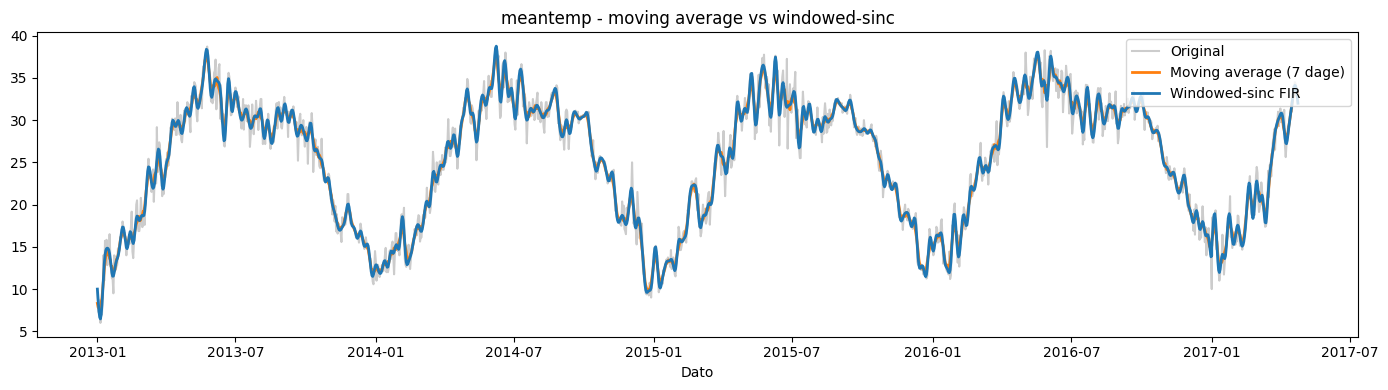

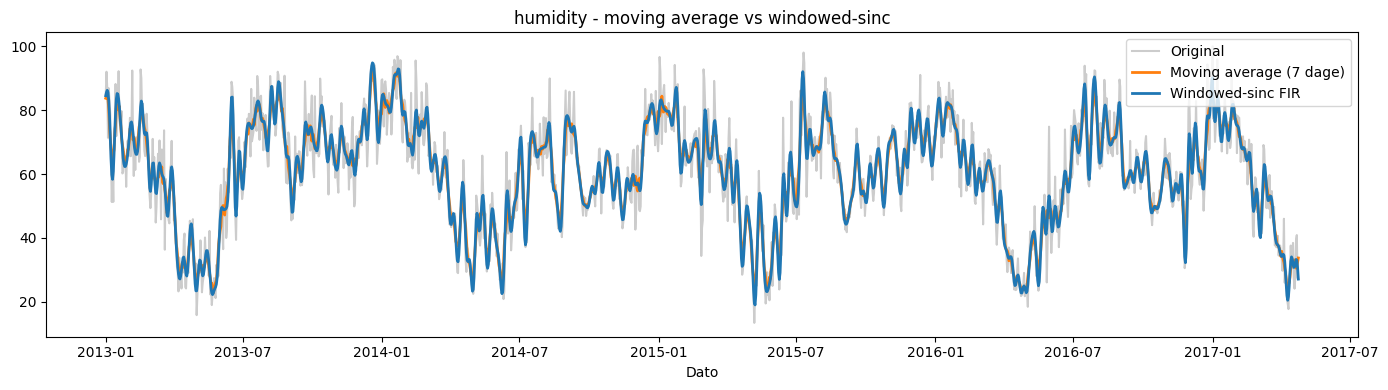

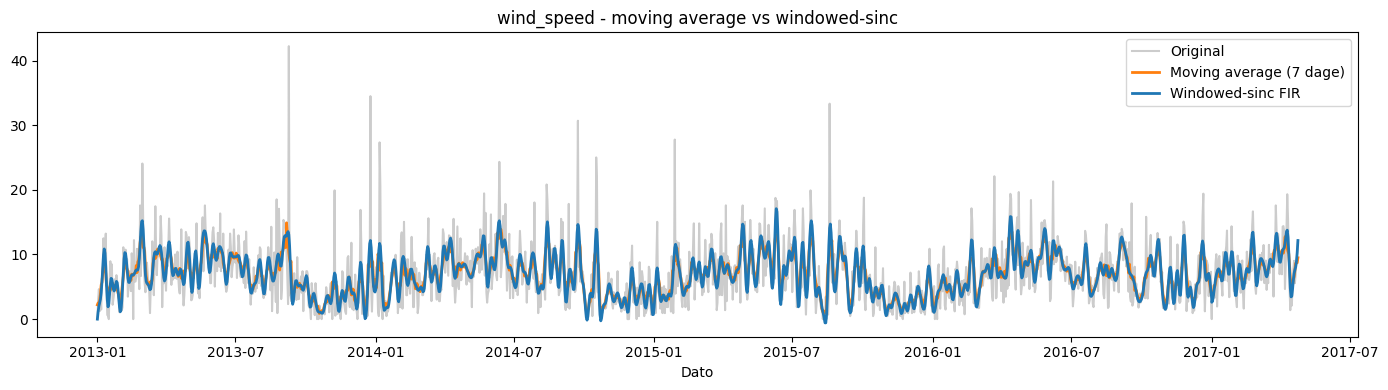

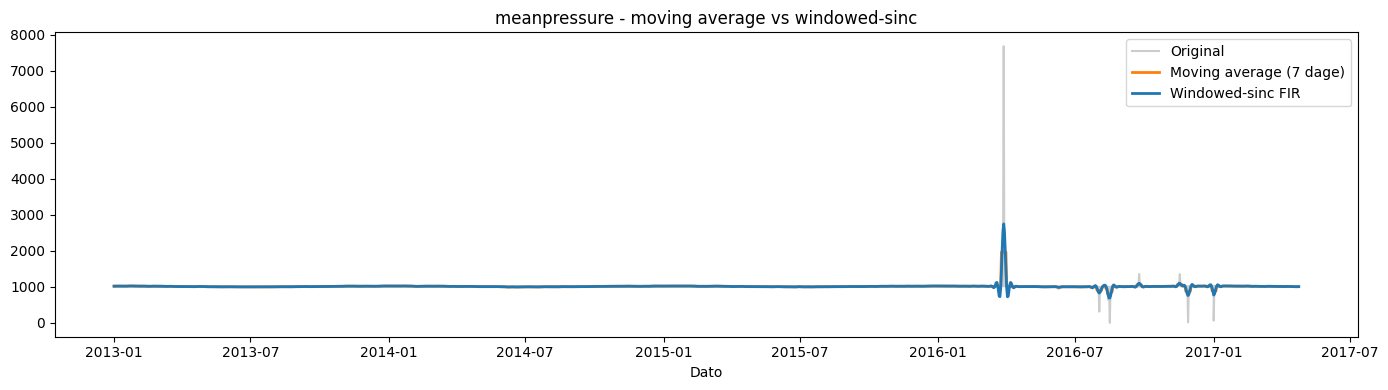

Sammenligning af moving average og windowed-sinc pr. tidsserie:


,serie,metode,residual_std,residual_ratio,variance_retained
3,humidity,windowed_sinc_fir,5.2617,0.3100,0.8862
2,humidity,moving_average_7,6.5326,0.3848,0.8113
7,meanpressure,windowed_sinc_fir,148.0949,0.8454,0.2430
6,meanpressure,moving_average_7,161.6904,0.9230,0.1465
1,meantemp,windowed_sinc_fir,1.0459,0.1424,0.9763
0,meantemp,moving_average_7,1.2919,0.1759,0.9581
5,wind_speed,windowed_sinc_fir,3.0186,0.6694,0.5058
4,wind_speed,moving_average_7,3.4884,0.7736,0.3627


Bedste metode pr. serie (lavest residual_ratio):


,serie,metode,residual_ratio,variance_retained
0,humidity,windowed_sinc_fir,0.3100,0.8862
1,meanpressure,windowed_sinc_fir,0.8454,0.2430
2,meantemp,windowed_sinc_fir,0.1424,0.9763
3,wind_speed,windowed_sinc_fir,0.6694,0.5058


In [9]:
# Sammenlign 2 metoder: moving average vs windowed-sinc FIR
window = 7
numtaps = 31
cutoff_cpd = 1 / 7  # cyklus pr. dag
fs = 1.0            # 1 observation pr. dag

# Windowed-sinc FIR design
fir_taps = signal.firwin(numtaps=numtaps, cutoff=cutoff_cpd, window='hamming', fs=fs)

comparison_rows = []

for col in numeric_cols:
    s = climate_df[col].astype(float)

    ma = s.rolling(window=window, center=True, min_periods=1).mean()
    ws = pd.Series(signal.filtfilt(fir_taps, [1.0], s.to_numpy()), index=s.index)

    # Plot: original + de 2 filtre
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(climate_df['date'], s, label='Original', alpha=0.4, color='gray')
    ax.plot(climate_df['date'], ma, label='Moving average (7 dage)', linewidth=2, color='tab:orange')
    ax.plot(climate_df['date'], ws, label='Windowed-sinc FIR', linewidth=2, color='tab:blue')
    ax.set_title(f'{col} - moving average vs windowed-sinc')
    ax.set_xlabel('Dato')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    s_std = s.std(ddof=0)
    s_var = s.var(ddof=0)

    for method_name, smooth in {
        'moving_average_7': ma,
        'windowed_sinc_fir': ws
    }.items():
        residual = s - smooth
        residual_std = residual.std(ddof=0)
        residual_ratio = residual_std / s_std if s_std != 0 else 0.0
        variance_retained = smooth.var(ddof=0) / s_var if s_var != 0 else 0.0

        comparison_rows.append({
            'serie': col,
            'metode': method_name,
            'residual_std': residual_std,
            'residual_ratio': residual_ratio,
            'variance_retained': variance_retained
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df[['residual_std', 'residual_ratio', 'variance_retained']] = comparison_df[
    ['residual_std', 'residual_ratio', 'variance_retained']
].round(4)

print('Sammenligning af moving average og windowed-sinc pr. tidsserie:')
display(comparison_df.sort_values(['serie', 'residual_ratio']))

best_per_series = comparison_df.sort_values('residual_ratio').groupby('serie', as_index=False).first()
print('Bedste metode pr. serie (lavest residual_ratio):')
display(best_per_series[['serie', 'metode', 'residual_ratio', 'variance_retained']])

### Celle 8 — Konklusion på modelsammenligning
På tværs af alle fire tidsserier giver windowed-sinc filteret den laveste `residual_ratio` i forhold til moving average, hvilket viser mere effektiv støjreduktion i denne analyse. Samtidig er `variance_retained` gennemgående højere for windowed-sinc, hvilket peger på bedre bevaring af signalets struktur.

For `meantemp` og `humidity` er forskellen tydeligst, og windowed-sinc fremstår som det mest balancerede valg. For `wind_speed` ses samme tendens, men begge metoder påvirkes af spidse udsving.

`meanpressure` er fortsat udfordret af ekstreme outliers; selv om windowed-sinc performer bedst af de to metoder, bør resultatet kombineres med robust outlier-håndtering (fx winsorisering eller filtrering) før endelig modellering.